# Valorización de viviendas en Cercado de Lima

## 1. Librerías e importaciones

In [1]:
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import xgboost as xgb
import time
import joblib
import json
import os

## 2. Lectura de datos

In [2]:
df = pd.read_excel('Predios_Cercado_de_Lima_Ene-Mar_2025_4.xlsx')
df.columns = ['num_registro', 'fecha_adquisicion', 'fecha_declaracion', 'num_persona',
              'tipo_propietario', 'pct_propiedad', 'num_predio', 'cod_uso_predio',
              'uso_predio', 'area_terreno', 'area_comun_terreno', 'area_construida',
              'area_comun_construida', 'area_total_construida', 'pisos',
              'anio_construccion', 'mayor_anio_construccion', 'material_predio',
              'valor_terreno', 'valor_construccion_dep', 'valor_obras_comp',
              'autovaluo', 'afecto_imp_predial']
print(f"Shape inicial: {df.shape}")
df.head()

Shape inicial: (229131, 23)


,num_registro,fecha_adquisicion,fecha_declaracion,num_persona,tipo_propietario,pct_propiedad,num_predio,cod_uso_predio,uso_predio,area_terreno,...,area_total_construida,pisos,anio_construccion,mayor_anio_construccion,material_predio,valor_terreno,valor_construccion_dep,valor_obras_comp,autovaluo,afecto_imp_predial
0,4470123114,2003-10-08,2007-04-27 08:49:00,6297598622,Propietario Único,100.00,5394658088,10101,Vivienda,40.00,...,40.00,1,2005.0,2005.0,Madera u otros,7400.00,5976.96,0.00,13376.96,N
1,3278827181,2007-02-15,2009-03-16 09:50:00,8518470230,Condómino,33.34,7776034160,10101,Vivienda,0.00,...,96.08,4,2006.0,2006.0,Concreto,8860.67,87527.55,1123.46,97511.68,S
2,9010805437,2009-04-06,2009-05-05 12:25:00,7290930932,Propietario Único,100.00,4928708754,10101,Vivienda,23.48,...,57.00,1,1965.0,1965.0,Ladrillo,6973.56,29012.37,0.00,35985.93,S
3,8960657151,1995-12-31,2012-04-09 15:15:00,8490356621,Propietario Único,100.00,6171978289,20201,Local de servicios (empresarial o profesional),0.00,...,18.00,1,1984.0,1984.0,Ladrillo,4884.75,7093.01,1686.31,13664.07,S
4,4085147639,2001-09-25,2007-03-28 08:19:00,5471080960,Propietario Único,100.00,3842922668,10101,Vivienda,0.00,...,56.53,2,1959.0,1959.0,Ladrillo,8257.92,21872.59,0.00,30130.51,S


In [3]:
df.isna().sum()

num_registro                  0
fecha_adquisicion             0
fecha_declaracion             0
num_persona                   0
tipo_propietario              0
pct_propiedad                 0
num_predio                    0
cod_uso_predio                0
uso_predio                    0
area_terreno                  0
area_comun_terreno            0
area_construida               0
area_comun_construida         0
area_total_construida         0
pisos                         0
anio_construccion          2996
mayor_anio_construccion    2996
material_predio               0
valor_terreno                 0
valor_construccion_dep        0
valor_obras_comp              0
autovaluo                     0
afecto_imp_predial            0
dtype: int64

## 3. Limpieza y transformación de datos

In [4]:
df_new = df.drop(columns=[
    'num_registro', 'num_persona', 'num_predio',
    'valor_terreno',
    #'autovaluo',
    'valor_construccion_dep', 'valor_obras_comp', "afecto_imp_predial"
])

df_new['fecha_adquisicion'] = pd.to_datetime(df_new['fecha_adquisicion'], errors='coerce')
df_new['fecha_declaracion']  = pd.to_datetime(df_new['fecha_declaracion'],  errors='coerce')

hoy = datetime.now()
df_new['Dias_entre_fechas']           = (df_new['fecha_adquisicion'] - df_new['fecha_declaracion']).dt.days
df_new['Antiguedad_Adquisicion_Dias'] = (hoy - df_new['fecha_adquisicion']).dt.days
df_new['Antiguedad_Declaracion_Dias'] = (hoy - df_new['fecha_declaracion']).dt.days
df_new['ant_constru']                 = hoy.year - df_new['mayor_anio_construccion']

df_new.drop(columns=['fecha_declaracion', 'fecha_adquisicion',
                     'anio_construccion', 'mayor_anio_construccion'], inplace=True)

uso_map = {
    'Vivienda': 'Vivienda', 'Deposito de vivienda': 'Vivienda',
    'Vivienda colectiva - habitaciones': 'Vivienda', 'Aires': 'Vivienda',
    'Bodega': 'Comercial',
    'Tienda por departamentos, supermercado, hiperbodega y similares': 'Comercial',
    'Puesto (o stand) en galería comercial': 'Comercial',
    'Puesto (o stand) en mercado o campo ferial': 'Comercial',
    'Galería comercial': 'Comercial', 'Mercado o campo ferial': 'Comercial',
    'Centro comercial': 'Comercial', 'Bazar y regalos': 'Comercial',
    'Comercial - no identificado': 'Comercial',
    'Otros usos comerciales no especificados': 'Comercial',
    'Oficina': 'Servicios',
    'Local de servicios (empresarial o profesional)': 'Servicios',
    'Estacionamiento de oficinas': 'Servicios', 'Depósito de oficina': 'Servicios',
    'Agencia de entidad financiera': 'Servicios', 'Sede de entidad financiera': 'Servicios',
    'Agencia de seguros o afp': 'Servicios', 'Correo o teléfono': 'Servicios',
    'Internet': 'Servicios', 'Centro de estética': 'Servicios',
    'Lavanderia de carros': 'Servicios', 'Ventas de departamentos': 'Servicios',
    'Industria manufacturera': 'Industrial', 'Taller': 'Industrial',
    'Almacén o depósito': 'Industrial', 'Tendal': 'Industrial',
    'Chatarrerías': 'Industrial',
    'Grifo venta de combustibles para vehiculos': 'Industrial',
    'Local venta de combustibles de uso doméstico': 'Industrial',
    'Distribución o transmisión de energía eléctrica': 'Industrial',
    'Sub-estación eléctrica o telefónica': 'Industrial',
    'Centro de captación, purificación y distribución de agua': 'Industrial',
    'Laboratorio de ensayos ambientales y similares': 'Industrial',
    'Educación inicial, primaria y/o secundaria': 'Educación',
    'Educación técnica y cenecapes': 'Educación',
    'Educación superior (universitaria o instituto)': 'Educación',
    'Educación pre universitaria (academia)': 'Educación',
    'Otros usos educativos nep': 'Educación', 'Cuna': 'Educación',
    'Hospital o clínica': 'Salud', 'Centro de salud': 'Salud',
    'Centro veterinario': 'Salud',
    'Hospicio, albergue, puericultorio o asilo': 'Salud',
    'Centro de rehabilitación y asistencia social (c.r.a.s.-cárceles)': 'Salud',
    'Otros usos de salud nep': 'Salud', 'Comedor popular': 'Salud',
    'Centro de asistencia social': 'Salud',
    'Restaurantes, bares y cantinas': 'Recreación',
    'Bingo, casino de juego, pinball, tragamonedas o similar': 'Recreación',
    'Club, círculo o centro deportivo': 'Recreación', 'Club social': 'Recreación',
    'Gimnasio y similares': 'Recreación', 'Cine': 'Recreación',
    'Teatro': 'Recreación',
    'Cafe teatro, cabaret, centro nocturno, boite': 'Recreación',
    'Peña, discoteca, salón de bailes o similares': 'Recreación',
    'Museo': 'Recreación', 'Centro cultural': 'Recreación',
    'Sala de exposición, galería de arte': 'Recreación',
    'Biblioteca': 'Recreación', 'Estadio, hipódromo o coliseo': 'Recreación',
    'Otros usos deportivos nep': 'Recreación',
    'Otros servicios de recreación o esparcimiento nep': 'Recreación',
    'Otros usos culturales nep': 'Recreación', 'Radio o televisión': 'Recreación',
    'Periodismo': 'Recreación',
    'Terreno sin construir': 'Sin construir', 'Cochera': 'Sin construir',
    'Playa o edificio de estacionamiento': 'Sin construir',
}

df_new.drop(columns=['cod_uso_predio'], inplace=True)
df_new['uso_predio'] = df_new['uso_predio'].map(uso_map).fillna('Otros')
df_new.to_csv('clean_data.csv', index=False)
print("clean_data.csv guardado.")

clean_data.csv guardado.


## 4. Filtro, Feature Engineering y Transformaciones

In [5]:
# --- Filtro solo viviendas ---
df_raw = df_new[df_new['uso_predio'] == 'Vivienda'].copy()
df_raw = df_raw[df_raw['area_terreno'] > 20].copy()
df_raw = df_raw.drop(columns=['uso_predio'])

limite_area     = df_raw['area_total_construida'].quantile(0.99)
limite_autovaluo = df_raw['autovaluo'].quantile(0.99)
df_raw = df_raw[
    (df_raw['area_total_construida'] <= limite_area) &
    (df_raw['autovaluo'] <= limite_autovaluo)
]
print(f"Registros vivienda (sin outliers): {len(df_raw):,}")

# --- Features derivadas ---
df_raw['pct_area_comun'] = np.where(
    df_raw['area_total_construida'] > 0,
    df_raw['area_comun_construida'] / df_raw['area_total_construida'], 0
)
df_raw['ratio_construccion_terreno'] = np.where(
    df_raw['area_terreno'] > 0,
    df_raw['area_total_construida'] / df_raw['area_terreno'], 0
)
df_raw = df_raw.drop(columns=['area_construida', 'area_comun_construida',
                               'area_comun_terreno', 'Dias_entre_fechas'])

# --- Transformación logarítmica ---
numerical_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns.tolist()
target_col = 'autovaluo'
df_log = df_raw.copy()
log_shifts = {}
for col in numerical_cols:
    min_val = df_log[col].min()
    log_shifts[col] = float(min_val) if min_val <= 0 else 0.0
    if min_val <= 0:
        df_log[col] = np.log1p(df_log[col] - min_val)
    else:
        df_log[col] = np.log1p(df_log[col])

# --- Encoding y partición ---
categorical_cols = df_log.select_dtypes(include=['str', 'category']).columns.tolist()
df_final = pd.get_dummies(df_log, columns=categorical_cols, drop_first=True)
feature_columns = [c for c in df_final.columns if c != target_col]

X = df_final[feature_columns]
y = df_final[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test  = pd.DataFrame(imputer.transform(X_test),      columns=X_test.columns)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features: {feature_columns}")

def evaluar(nombre, y_test, y_pred_log):
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2   = r2_score(y_test_real, y_pred_real)
    print(f"\n{'='*45}")
    print(f"MÉTRICAS: {nombre} (Test 20%) — escala real")
    print(f"{'='*45}")
    print(f"MAE  (Error Absoluto Medio)       : {mae:,.2f}")
    print(f"RMSE (Raíz del Error Cuadrático)  : {rmse:,.2f}")
    print(f"R²   (Coeficiente Determinación)  : {r2:.4f}")
    print(f"{'='*45}\n")
    return float(mae), float(rmse), float(r2)

Registros vivienda (sin outliers): 49,881
X_train: (39904, 17) | X_test: (9977, 17)
Features: ['pct_propiedad', 'area_terreno', 'area_total_construida', 'pisos', 'Antiguedad_Adquisicion_Dias', 'Antiguedad_Declaracion_Dias', 'ant_constru', 'pct_area_comun', 'ratio_construccion_terreno', 'tipo_propietario_Condómino', 'tipo_propietario_Poseedor', 'tipo_propietario_Propietario Único', 'tipo_propietario_Responsable', 'material_predio_Concreto', 'material_predio_Ladrillo', 'material_predio_Madera u otros', 'material_predio_No declarado']


## 5. Modelo 1: Random Forest

Tiempo de entrenamiento RF: 2.01 s

MÉTRICAS: RANDOM FOREST (Test 20%) — escala real
MAE  (Error Absoluto Medio)       : 10,705.88
RMSE (Raíz del Error Cuadrático)  : 20,050.18
R²   (Coeficiente Determinación)  : 0.9446

Top variables — Random Forest:
                          Variable  Importancia
             area_total_construida     0.820149
                      area_terreno     0.056500
                       ant_constru     0.025973
          material_predio_Ladrillo     0.025470
          material_predio_Concreto     0.015148
        ratio_construccion_terreno     0.014420
       Antiguedad_Declaracion_Dias     0.013636
       Antiguedad_Adquisicion_Dias     0.011539
                    pct_area_comun     0.005641
                             pisos     0.005362
                     pct_propiedad     0.003988
tipo_propietario_Propietario Único     0.000696
        tipo_propietario_Condómino     0.000682
    material_predio_Madera u otros     0.000331
         tipo_propietario_Po

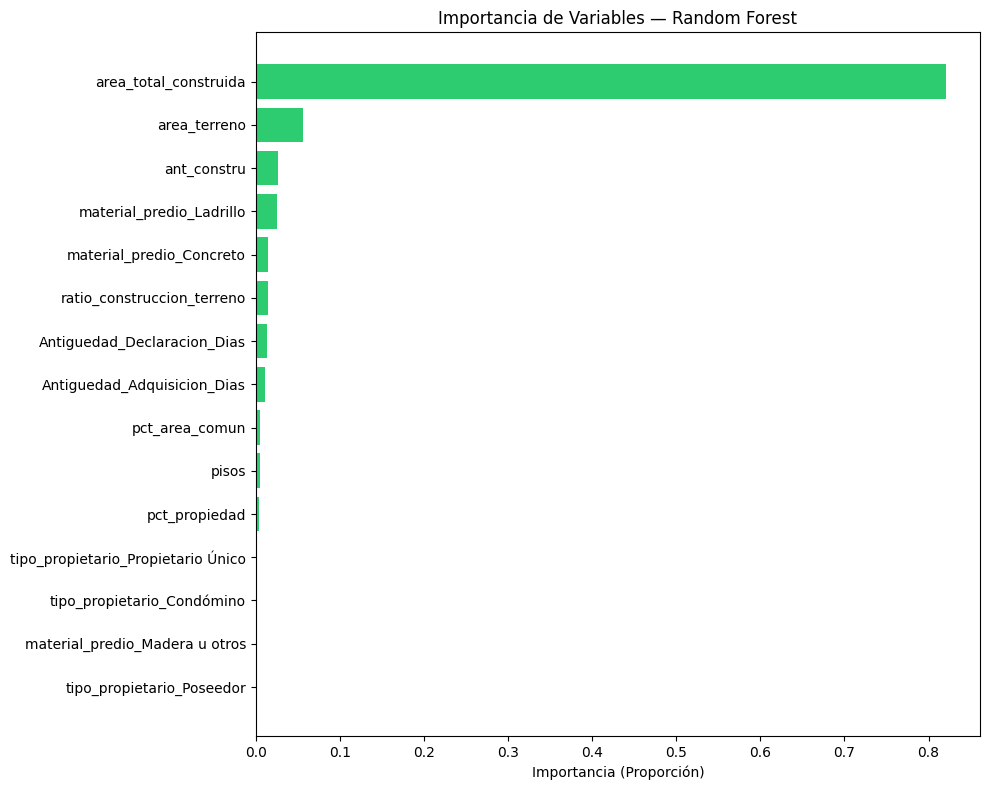

In [6]:
inicio_rf = time.perf_counter()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
fin_rf = time.perf_counter()
tiempo_rf = fin_rf - inicio_rf
print(f"Tiempo de entrenamiento RF: {tiempo_rf:.2f} s")

mae_rf, rmse_rf, r2_rf = evaluar('RANDOM FOREST', y_test, rf.predict(X_test))

feat_imp_rf = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)
print("Top variables — Random Forest:")
print(feat_imp_rf.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_rf['Variable'].head(15), feat_imp_rf['Importancia'].head(15), color='#2ecc71')
plt.xlabel('Importancia (Proporción)')
plt.title('Importancia de Variables — Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 5.1 GridSearchCV — Random Forest

In [ ]:
# ============================================================
# GRID SEARCH — RANDOM FOREST
# ============================================================
param_grid_rf = {
    'n_estimators':    [100, 200],
    'max_depth':       [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':    ['sqrt', 0.5],
}

gs_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

print('Iniciando GridSearch Random Forest...')
inicio_rf_gs = time.perf_counter()
gs_rf.fit(X_train, y_train)
tiempo_rf_gs = time.perf_counter() - inicio_rf_gs

print(f'\nMejores hiperparámetros RF:')
for k, v in gs_rf.best_params_.items():
    print(f'  {k}: {v}')
print(f'Mejor R² (CV): {gs_rf.best_score_:.4f}')
print(f'Tiempo GridSearch RF: {tiempo_rf_gs:.1f} s')

# Evaluar modelo tuneado
rf_tuned = gs_rf.best_estimator_
mae_rf_t, rmse_rf_t, r2_rf_t = evaluar('RANDOM FOREST (Tuneado)', y_test, rf_tuned.predict(X_test))

# Feature importance del modelo tuneado
feat_imp_rf_t = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_tuned.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_rf_t['Variable'].head(15), feat_imp_rf_t['Importancia'].head(15), color='#27ae60')
plt.xlabel('Importancia (Proporción)')
plt.title('Importancia de Variables — Random Forest (Tuneado)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Iniciando GridSearch Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits


## 6. Modelo 2: XGBoost

In [ ]:
inicio_xgb = time.perf_counter()
model_xgb = xgb.XGBRegressor(random_state=42)
model_xgb.fit(X_train, y_train)
fin_xgb = time.perf_counter()
tiempo_xgb = fin_xgb - inicio_xgb
print(f"Tiempo de entrenamiento XGB: {tiempo_xgb:.2f} s")

mae_xgb, rmse_xgb, r2_xgb = evaluar('XGBOOST', y_test, model_xgb.predict(X_test))

feat_imp_xgb = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': model_xgb.feature_importances_
}).sort_values('Importancia', ascending=False)
print("Top variables — XGBoost:")
print(feat_imp_xgb.to_string(index=False))

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_xgb['Variable'].head(15), feat_imp_xgb['Importancia'].head(15), color='#3498db')
plt.xlabel('Importancia (Proporción)')
plt.title('Importancia de Variables — XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6.1 GridSearchCV — XGBoost

In [ ]:
# ============================================================
# GRID SEARCH — XGBOOST
# ============================================================
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

gs_xgb = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_grid_xgb,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

print('Iniciando GridSearch XGBoost...')
inicio_xgb_gs = time.perf_counter()
gs_xgb.fit(X_train, y_train)
tiempo_xgb_gs = time.perf_counter() - inicio_xgb_gs

print(f'\nMejores hiperparámetros XGB:')
for k, v in gs_xgb.best_params_.items():
    print(f'  {k}: {v}')
print(f'Mejor R² (CV): {gs_xgb.best_score_:.4f}')
print(f'Tiempo GridSearch XGB: {tiempo_xgb_gs:.1f} s')

# Evaluar modelo tuneado
model_xgb_tuned = gs_xgb.best_estimator_
mae_xgb_t, rmse_xgb_t, r2_xgb_t = evaluar('XGBOOST (Tuneado)', y_test, model_xgb_tuned.predict(X_test))

# Feature importance del modelo tuneado
feat_imp_xgb_t = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': model_xgb_tuned.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feat_imp_xgb_t['Variable'].head(15), feat_imp_xgb_t['Importancia'].head(15), color='#2980b9')
plt.xlabel('Importancia (Proporción)')
plt.title('Importancia de Variables — XGBoost (Tuneado)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Modelo 3: Red Neuronal (MLP)

In [ ]:
inicio_rnn = time.perf_counter()
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)
print("Entrenando Red Neuronal...")
mlp.fit(X_train_scaled, y_train)
fin_rnn = time.perf_counter()
tiempo_rnn = fin_rnn - inicio_rnn
print(f"Tiempo de entrenamiento MLP: {tiempo_rnn:.2f} s")

mae_rnn, rmse_rnn, r2_rnn = evaluar('RED NEURONAL (MLP)', y_test, mlp.predict(X_test_scaled))

### 7.1 GridSearchCV — Red Neuronal (MLP)

In [ ]:
# ============================================================
# GRID SEARCH — RED NEURONAL (MLP)
# ============================================================
param_grid_mlp = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16)],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01],
}

gs_mlp = GridSearchCV(
    MLPRegressor(solver='adam', max_iter=500, early_stopping=True, random_state=42),
    param_grid_mlp,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
)

print('Iniciando GridSearch MLP...')
inicio_mlp_gs = time.perf_counter()
gs_mlp.fit(X_train_scaled, y_train)
tiempo_mlp_gs = time.perf_counter() - inicio_mlp_gs

print(f'\nMejores hiperparámetros MLP:')
for k, v in gs_mlp.best_params_.items():
    print(f'  {k}: {v}')
print(f'Mejor R² (CV): {gs_mlp.best_score_:.4f}')
print(f'Tiempo GridSearch MLP: {tiempo_mlp_gs:.1f} s')

# Evaluar modelo tuneado
mlp_tuned = gs_mlp.best_estimator_
mae_rnn_t, rmse_rnn_t, r2_rnn_t = evaluar('RED NEURONAL (Tuneada)', y_test, mlp_tuned.predict(X_test_scaled))

## 8. Resumen comparativo — Base vs Tuneado

In [ ]:
resumen = pd.DataFrame({
    'RF Base':       {'R²': r2_rf,    'MAE': mae_rf,    'RMSE': rmse_rf},
    'RF Tuneado':    {'R²': r2_rf_t,  'MAE': mae_rf_t,  'RMSE': rmse_rf_t},
    'XGB Base':      {'R²': r2_xgb,   'MAE': mae_xgb,   'RMSE': rmse_xgb},
    'XGB Tuneado':   {'R²': r2_xgb_t, 'MAE': mae_xgb_t, 'RMSE': rmse_xgb_t},
    'MLP Base':      {'R²': r2_rnn,   'MAE': mae_rnn,   'RMSE': rmse_rnn},
    'MLP Tuneada':   {'R²': r2_rnn_t, 'MAE': mae_rnn_t, 'RMSE': rmse_rnn_t},
})
print('\n===== RESUMEN COMPARATIVO: BASE vs TUNEADO =====')
print(resumen.round(4).to_string())

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nombres_b  = ['RF Base', 'XGB Base', 'MLP Base']
nombres_t  = ['RF Tuneado', 'XGB Tuneado', 'MLP Tuneada']
colores_b  = ['#2ecc71', '#3498db', '#e67e22']
colores_t  = ['#27ae60', '#2980b9', '#d35400']

for ax, (metrica, vals_b, vals_t) in zip(axes, [
    ('R²',         [r2_rf,   r2_xgb,   r2_rnn],   [r2_rf_t,   r2_xgb_t,   r2_rnn_t]),
    ('MAE (S/)',   [mae_rf,  mae_xgb,  mae_rnn],  [mae_rf_t,  mae_xgb_t,  mae_rnn_t]),
    ('RMSE (S/)',  [rmse_rf, rmse_xgb, rmse_rnn], [rmse_rf_t, rmse_xgb_t, rmse_rnn_t]),
]):
    x = np.arange(3)
    w = 0.35
    bars_b = ax.bar(x - w/2, vals_b, w, label='Base',    color=colores_b, edgecolor='white', alpha=0.85)
    bars_t = ax.bar(x + w/2, vals_t, w, label='Tuneado', color=colores_t, edgecolor='white')
    ax.set_title(metrica, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(['RF', 'XGB', 'MLP'], fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8)
    all_vals = vals_b + vals_t
    for bar, v in zip(list(bars_b) + list(bars_t), all_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(all_vals)*0.01,
                f'{v:.4f}' if metrica == 'R²' else f'{v:,.0f}',
                ha='center', fontsize=7, fontweight='bold')

plt.suptitle('Comparación Base vs Tuneado — Cercado de Lima 2025', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de mejores hiperparámetros
print('\n===== MEJORES HIPERPARÁMETROS =====')
print('\n[Random Forest]')
for k, v in gs_rf.best_params_.items():  print(f'  {k}: {v}')
print('\n[XGBoost]')
for k, v in gs_xgb.best_params_.items(): print(f'  {k}: {v}')
print('\n[MLP]')
for k, v in gs_mlp.best_params_.items(): print(f'  {k}: {v}')

## 9. Exportación de modelos y métricas

In [ ]:
# ============================================================
# EXPORTACIÓN DE MODELOS TUNEADOS, PREPROCESADORES Y MÉTRICAS
# ============================================================
os.makedirs('models', exist_ok=True)

# --- Modelos tuneados (mismos nombres que el app.py espera) ---
joblib.dump(rf_tuned,        'models/rf_model.joblib')
joblib.dump(model_xgb_tuned, 'models/xgb_model.joblib')
joblib.dump(mlp_tuned,       'models/mlp_model.joblib')
print('✅ Modelos tuneados guardados: rf_model.joblib | xgb_model.joblib | mlp_model.joblib')

# --- Preprocesadores ---
joblib.dump(imputer,         'models/imputer.joblib')
joblib.dump(scaler,          'models/scaler.joblib')
joblib.dump(feature_columns, 'models/feature_columns.joblib')
joblib.dump(feat_imp_rf_t,   'models/feat_imp_rf.joblib')
joblib.dump(feat_imp_xgb_t,  'models/feat_imp_xgb.joblib')
print('✅ Preprocesadores guardados: imputer.joblib | scaler.joblib | feature_columns.joblib')

# --- Métricas en JSON ---
metrics_dict = {
    'Random Forest': {'R2': r2_rf_t,  'MAE': mae_rf_t,  'RMSE': rmse_rf_t,  'Tiempo_s': round(tiempo_rf_gs, 2)},
    'XGBoost':       {'R2': r2_xgb_t, 'MAE': mae_xgb_t, 'RMSE': rmse_xgb_t, 'Tiempo_s': round(tiempo_xgb_gs, 2)},
    'Red Neuronal':  {'R2': r2_rnn_t, 'MAE': mae_rnn_t, 'RMSE': rmse_rnn_t, 'Tiempo_s': round(tiempo_mlp_gs, 2)},
}
with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics_dict, f, indent=2, ensure_ascii=False)
print('✅ Métricas guardadas: models/metrics.json')

# --- Info de preprocesamiento ---
preprocessing_info = {
    'log_shifts':               log_shifts,
    'numerical_cols':           numerical_cols,
    'categorical_cols':         categorical_cols,
    'feature_columns':          feature_columns,
    'tipo_propietario_values':  list(df_raw['tipo_propietario'].dropna().unique()),
    'material_predio_values':   list(df_raw['material_predio'].dropna().unique()),
    'area_terreno_median':      float(df_raw['area_terreno'].median()),
    'area_total_construida_median': float(df_raw['area_total_construida'].median()),
}
with open('models/preprocessing_info.json', 'w', encoding='utf-8') as f:
    json.dump(preprocessing_info, f, indent=2, ensure_ascii=False)
print('✅ Preprocesamiento guardado: models/preprocessing_info.json')

print('\n📁 Archivos generados en models/:')
for file in sorted(os.listdir('models')):
    size_kb = os.path.getsize(f'models/{file}') / 1024
    print(f'   {file:40s} {size_kb:8.1f} KB')